# 06-1. Latent Space Arithmetic — PyTorch

학습된 VAE의 잠재 공간에서 벡터 연산으로 이미지 속성을 제어합니다.

| 연산 | 수식 | 의미 |
|------|------|---------|
| 기본 산술 | `z_A - z_B + z_C` | B의 특성을 A에서 빼고 C에 더함 |
| 방향 벡터 | `mean(그룹A) - mean(그룹B)` | 두 그룹의 차이 방향 추출 |
| 속성 이식 | `z_target + α × 방향벡터` | 강도(α) 조절로 속성 적용 |

## 1. 환경 설정

In [129]:
import os, json, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image

# CWD 고정
_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p); break
print(f'CWD: {Path.cwd()}')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

CWD: /Users/gomuseo/Desktop/Python/vae_test
Device: mps


## 2. 모델 로드

In [130]:
CKPT_DIR = Path('checkpoints_pt')

with open(CKPT_DIR / 'config.json') as f:
    CFG = json.load(f)

LATENT_DIM = CFG['latent_dim']
BASE_CH    = CFG['base_channels']
CHANNELS   = CFG['channels']
print(f'latent_dim={LATENT_DIM}  base_ch={BASE_CH}')


class Encoder(nn.Module):
    def __init__(self, channels=4, base_ch=32, latent_dim=128):
        super().__init__()
        layers, in_ch, ch = [], channels, base_ch
        for _ in range(4):
            layers += [nn.Conv2d(in_ch, ch, 4, stride=2, padding=1),
                       nn.BatchNorm2d(ch, momentum=0.1),
                       nn.LeakyReLU(0.2)]
            in_ch = ch; ch *= 2
        self.conv     = nn.Sequential(*layers)
        self.flat_dim = (base_ch * 8) * 4 * 4
        self.fc_mu    = nn.Linear(self.flat_dim, latent_dim)
        self.fc_lv    = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)


class Decoder(nn.Module):
    def __init__(self, channels=4, base_ch=32, latent_dim=128):
        super().__init__()
        self.start_ch = base_ch * 8
        self.fc       = nn.Linear(latent_dim, self.start_ch * 4 * 4)
        layers, in_ch = [], self.start_ch
        for i, out_ch in enumerate([base_ch*4, base_ch*2, base_ch, channels]):
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1))
            if i < 3:
                layers += [nn.BatchNorm2d(out_ch, momentum=0.1), nn.ReLU()]
            else:
                layers.append(nn.Sigmoid())
            in_ch = out_ch
        self.deconv = nn.Sequential(*layers)

    def forward(self, z):
        return self.deconv(self.fc(z).view(-1, self.start_ch, 4, 4))


class VAE(nn.Module):
    def __init__(self, channels=4, base_ch=32, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(channels, base_ch, latent_dim)
        self.decoder = Decoder(channels, base_ch, latent_dim)

    def forward(self, x):
        mu, lv = self.encoder(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.decoder(z), mu, lv


model = VAE(CHANNELS, BASE_CH, LATENT_DIM).to(DEVICE)
model.load_state_dict(torch.load(CKPT_DIR / 'best.pt', map_location=DEVICE))
model.eval()
print('모델 로드 완료.')

latent_dim=128  base_ch=32
모델 로드 완료.


## 3. 이미지 로드 & 인코딩 유틸

In [131]:
BODY_DIR  = Path('dataset/processed/body')
all_paths = sorted(BODY_DIR.glob('*.png'))
print(f'body 이미지: {len(all_paths):,}장')

to_tensor = transforms.ToTensor()


def load_imgs(paths):
    """경로 리스트 → (N, 4, 64, 64) float32 텐서 [0,1]"""
    return torch.stack([
        to_tensor(Image.open(p).convert('RGBA')) for p in paths
    ]).to(DEVICE)


@torch.no_grad()
def encode(imgs):
    """이미지 텐서 → μ 벡터 (결정론적, 재현성 보장)"""
    mu, _ = model.encoder(imgs)
    return mu


@torch.no_grad()
def decode(z):
    """잠재 벡터 → 이미지 텐서"""
    return model.decoder(z)


BG = np.array([0.82, 0.82, 0.82])

def composite(tensor):
    """RGBA 텐서 (C,H,W) → RGB numpy (알파 합성)"""
    arr   = tensor.cpu().permute(1, 2, 0).numpy()
    alpha = arr[:, :, 3:4]
    return np.clip(arr[:, :, :3] * alpha + BG * (1 - alpha), 0, 1)


def show_row(images, labels=None, title=None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.8))
    if n == 1: axes = [axes]
    for ax, img, lbl in zip(axes, images, labels or [''] * n):
        ax.imshow(composite(img))
        ax.set_title(lbl, fontsize=7)
        ax.axis('off')
    if title: plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


print('유틸 함수 정의 완료.')

body 이미지: 4,544장
유틸 함수 정의 완료.


## 4. 기본 산술 — z_A - z_B + z_C

A의 특성에서 B의 특성을 빼고 C의 특성을 더합니다.

In [132]:
def find(keyword):
    return [p for p in all_paths if keyword in p.name]

# 예시: 키워드로 이미지 찾기
# candidates = find('walk')
# print([p.name for p in candidates[:5]])

import time
random.seed(time.time())
sample = random.sample(all_paths, 3)
path_A, path_B, path_C = sample

print(f'A: {path_A.name}')
print(f'B: {path_B.name}')
print(f'C: {path_C.name}')

A: pregnant_walk_3_0.png
B: bodies_female_backslash_1_4_flip.png
C: muscular_slash_1_4_flip.png


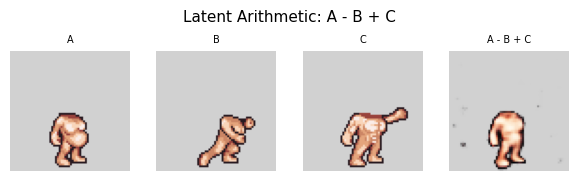

In [133]:
imgs_ABC = load_imgs([path_A, path_B, path_C])
z_A, z_B, z_C = encode(imgs_ABC)

# z_A - z_B + z_C
z_result  = z_A - z_B + z_C
img_result = decode(z_result.unsqueeze(0))

show_row(
    [imgs_ABC[0], imgs_ABC[1], imgs_ABC[2], img_result[0]],
    labels=['A', 'B', 'C', 'A - B + C'],
    title='Latent Arithmetic: A - B + C'
)

## 5. 방향 벡터 추출

두 그룹의 평균 잠재 벡터 차이로 속성 방향을 추출합니다.

```
방향벡터 = mean(그룹A의 z) - mean(그룹B의 z)
```

사용 가능한 키워드 목록을 확인한 뒤 `KEYWORD_A`, `KEYWORD_B`를 설정하세요.

In [134]:
# 파일명 토큰을 분석해 사용 가능한 키워드와 빈도를 출력합니다.
from collections import Counter

# 숫자·flip·bodies 등 의미 없는 토큰 제외
EXCLUDE = {'bodies', 'flip', 'body'}

tokens = Counter()
for p in all_paths:
    parts = p.stem.split('_')
    for part in parts:
        if not part.isdigit() and part not in EXCLUDE:
            tokens[part] += 1

# 빈도순 정렬 출력
print(f"{'키워드':>20}  {'파일 수':>8}")
print('-' * 33)
for token, count in tokens.most_common():
    print(f'{token:>20}  {count:>8,}')

                 키워드      파일 수
---------------------------------
              female       916
                male       916
                teen       916
                walk       864
            pregnant       764
            muscular       608
               slash       576
                jump       480
               child       424
               shoot       416
                 run       320
              thrust       320
           backslash       312
                 sit       288
           spellcast       280
                idle       256
                hurt       144
           halfslash       144
               emote        96
              combat        64
               climb        48


In [135]:
# ── 그룹 설정 ───────────────────────────────────────────
# 파일명 키워드로 두 그룹을 나눕니다.
# 아래 키워드를 실제 파일명에 맞게 수정하세요.

KEYWORD_A = 'walk'    # 그룹 A 키워드
KEYWORD_B = 'female'  # 그룹 B 키워드

group_A_paths = find(KEYWORD_A)[:50]
group_B_paths = find(KEYWORD_B)[:50]

print(f'그룹 A ({KEYWORD_A}): {len(group_A_paths)}장')
print(f'그룹 B ({KEYWORD_B}): {len(group_B_paths)}장')

if not group_A_paths or not group_B_paths:
    print('\n키워드에 해당하는 파일이 없습니다. KEYWORD_A / KEYWORD_B를 수정하세요.')
    print('파일명 예시:', [p.name for p in random.sample(list(all_paths), 5)])

그룹 A (walk): 50장
그룹 B (female): 50장


방향 벡터 norm: 3.3777


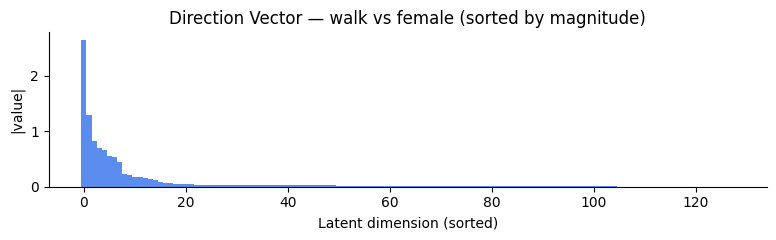

In [136]:
imgs_A = load_imgs(group_A_paths)
imgs_B = load_imgs(group_B_paths)

z_A_mean  = encode(imgs_A).mean(dim=0)
z_B_mean  = encode(imgs_B).mean(dim=0)
direction = z_A_mean - z_B_mean

print(f'방향 벡터 norm: {direction.norm().item():.4f}')

# 방향 벡터 크기 분포 시각화
d_np = direction.cpu().numpy()
plt.figure(figsize=(8, 2.5))
plt.bar(range(len(d_np)), np.sort(np.abs(d_np))[::-1],
        color='#5b8dee', width=1.0)
plt.title(f'Direction Vector — {KEYWORD_A} vs {KEYWORD_B} (sorted by magnitude)')
plt.xlabel('Latent dimension (sorted)'); plt.ylabel('|value|')
for spine in ['top', 'right']: plt.gca().spines[spine].set_visible(False)
plt.tight_layout(); plt.show()

## 6. 속성 이식 — 강도(α) 조절

방향 벡터를 대상 이미지의 잠재 벡터에 더해 속성을 이식합니다.

```
z_결과 = z_대상 + α × 방향벡터
```

- **α = 0** : 원본 유지
- **α > 0** : 그룹 A 방향으로 속성 이동
- **α < 0** : 그룹 B 방향으로 속성 이동
- α 절댓값이 클수록 속성 변화 강도가 세짐

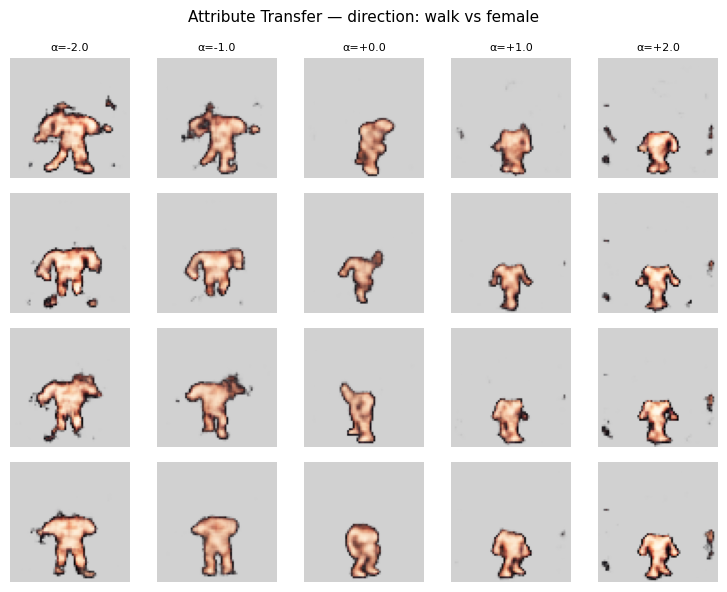

In [137]:
target_paths = random.sample(list(all_paths), 4)
target_imgs  = load_imgs(target_paths)
z_targets    = encode(target_imgs)

alphas = [-2.0, -1.0, 0.0, 1.0, 2.0]

fig, axes = plt.subplots(len(target_paths), len(alphas),
                         figsize=(len(alphas) * 1.5, len(target_paths) * 1.5))
axes = np.array(axes).reshape(len(target_paths), len(alphas))

for row, z_t in enumerate(z_targets):
    for col, alpha in enumerate(alphas):
        z_mod   = z_t + alpha * direction
        img_out = decode(z_mod.unsqueeze(0))
        axes[row, col].imshow(composite(img_out[0]))
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'α={alpha:+.1f}', fontsize=8)

plt.suptitle(f'Attribute Transfer — direction: {KEYWORD_A} vs {KEYWORD_B}', fontsize=11)
plt.tight_layout()
plt.show()

## 7. 여러 방향 벡터 합성

두 개의 방향 벡터를 동시에 적용해 여러 속성을 한 번에 이식합니다.

```
z_결과 = z_대상 + α1 × 방향벡터1 + α2 × 방향벡터2
```

- **방향벡터1** : 섹션 5의 `KEYWORD_A vs KEYWORD_B`
- **방향벡터2** : 이 섹션의 `KEYWORD_C vs KEYWORD_D`
- 각 방향벡터의 강도(`alpha1`, `alpha2`)를 독립적으로 조절 가능

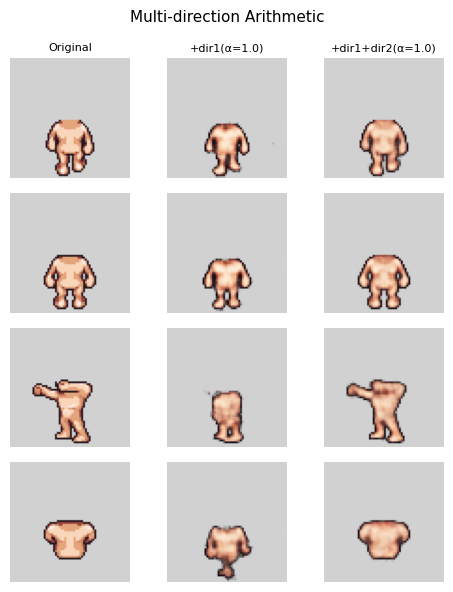

In [138]:
# ── 추가 방향 벡터 ──────────────────────────────────────
# 두 번째 방향벡터를 정의해 동시에 적용합니다.

KEYWORD_C = 'male'   # 세 번째 그룹 키워드
KEYWORD_D = 'walk'   # 네 번째 그룹 키워드

group_C_paths = find(KEYWORD_C)[:50]
group_D_paths = find(KEYWORD_D)[:50]

if group_C_paths and group_D_paths:
    z_C_mean   = encode(load_imgs(group_C_paths)).mean(dim=0)
    z_D_mean   = encode(load_imgs(group_D_paths)).mean(dim=0)
    direction2 = z_C_mean - z_D_mean

    t_paths = random.sample(list(all_paths), 4)
    t_imgs  = load_imgs(t_paths)
    z_ts    = encode(t_imgs)

    alpha1, alpha2 = 1.0, 1.0

    fig, axes = plt.subplots(len(t_paths), 3, figsize=(5, len(t_paths) * 1.5))
    axes = np.array(axes).reshape(len(t_paths), 3)

    for row, (z_t, orig) in enumerate(zip(z_ts, t_imgs)):
        z_mod   = z_t + alpha1 * direction + alpha2 * direction2
        img_out = decode(z_mod.unsqueeze(0))
        axes[row, 0].imshow(composite(orig)); axes[row, 0].axis('off')
        axes[row, 1].imshow(composite(decode((z_t + alpha1 * direction).unsqueeze(0))[0]))
        axes[row, 1].axis('off')
        axes[row, 2].imshow(composite(img_out[0])); axes[row, 2].axis('off')
        if row == 0:
            for ax, lbl in zip(axes[0], ['Original', f'+dir1(α={alpha1})', f'+dir1+dir2(α={alpha2})']):
                ax.set_title(lbl, fontsize=8)

    plt.suptitle('Multi-direction Arithmetic', fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print('KEYWORD_C / KEYWORD_D를 설정하면 두 방향 벡터를 동시에 적용할 수 있습니다.')